In [1]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import torch

from sklearn.model_selection import train_test_split

from torch.utils.data import DataLoader
from torchvision import datasets

from src.result_plots import (
    dataset_class_distribution,
    segmentation_class_distribution,
    plot_yolo_training_results,
    plot_conf_matrix_yolo,
    train_val_acc_loss_plot,
    conf_matrix_heatmap,
    plot_nlp_training_results,
)

from src.dataset import (
    PascalViewDataset,
    VehicleDataset,
    CarPartsSegmentationDataset,
)

PLOTS_PATH = Path("./plots")
PLOTS_PATH.mkdir(parents=True, exist_ok=True)
PROJECT_DIR = Path.cwd()
RANDOM_STATE = 42 

plt.style.use('ggplot')
plot_colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

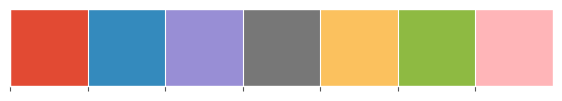

In [2]:
sns.palplot(plot_colors)

## Color detection

Total images: 7267


,class,count
0,beige,421
1,black,406
2,blue,742
3,brown,565
4,gold,210
5,green,563
6,grey,428
7,orange,534
8,pink,483
9,purple,536


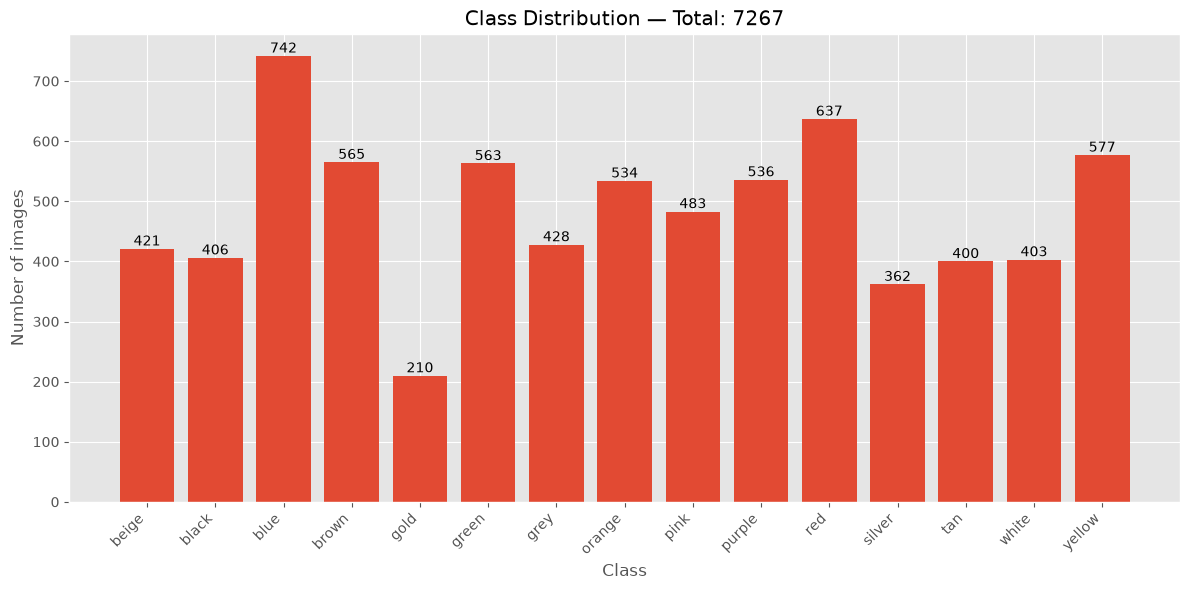

In [3]:
color_distribution_df = dataset_class_distribution("./datasets/car_color/train", 'color_distribution_plot')

In [4]:
train_color_detection_results = torch.load('./trained_pytorch_models/color/results_EfficientNet_B0.pth', weights_only=False)

In [5]:
color_df = train_color_detection_results['history_df']
display(color_df)

,train_loss,train_acc,test_loss,test_acc
0,1.154165,0.627081,0.710867,0.760155
1,0.675409,0.770332,0.541930,0.802708
2,0.577635,0.801294,0.503913,0.807866
3,0.504957,0.819458,0.467413,0.826564
4,0.463120,0.838448,0.490648,0.823340
5,0.438049,0.842576,0.471309,0.828498
6,0.396432,0.859639,0.503332,0.821406
7,0.367540,0.869547,0.444002,0.844616
8,0.321192,0.883446,0.521708,0.826564
9,0.347886,0.877253,0.475078,0.842037


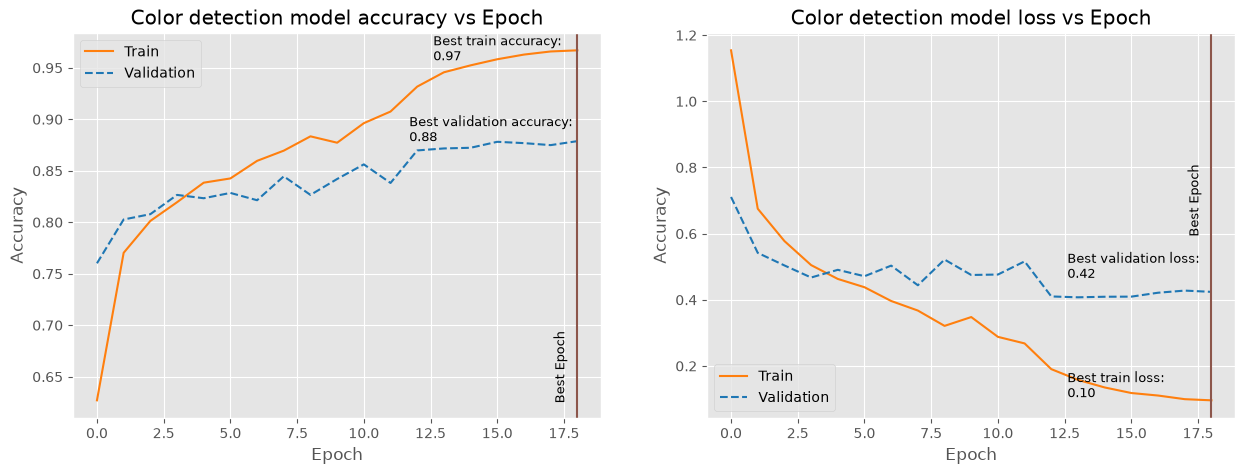

In [6]:
train_val_acc_loss_plot(train_color_detection_results, "Color detection", "color_detection_results")

In [7]:
test_color_detection_results = torch.load('./trained_pytorch_models/color/test_results.pth', weights_only=False)

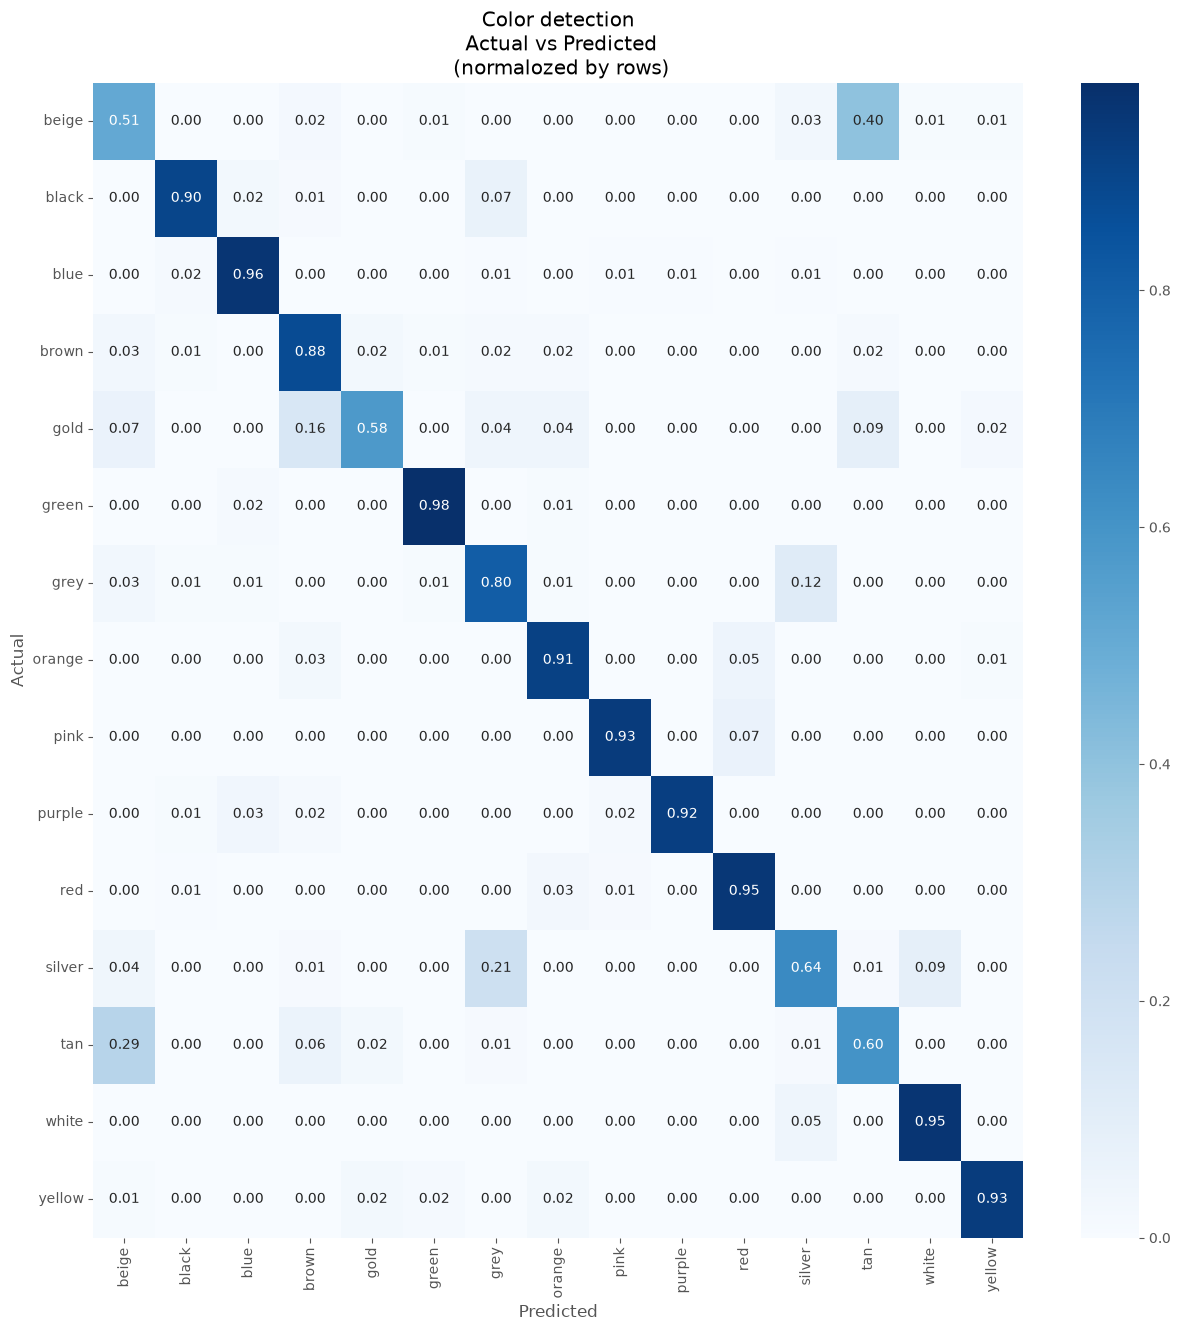

In [8]:
conf_matrix_heatmap(test_color_detection_results, "Color detection", "color_detection_heatmap")

## Orirntation ditection¶

In [9]:
ORIENTATION_DATA = (
    PROJECT_DIR
    / "datasets"
    / "PASCAL3D+"
).resolve()

all_image_paths = sorted(
    (ORIENTATION_DATA/ "Images" / "car_imagenet").glob("*.JPEG")
)

train_orientation_paths, temp_paths = train_test_split(
    all_image_paths,
    test_size=0.40,
    random_state=RANDOM_STATE,
    shuffle=True,
)

train_orientation_dataset = PascalViewDataset(
    root=ORIENTATION_DATA,
    image_paths=train_orientation_paths,
)

Total images: 3285


,class,count
0,front,535
1,front_left,768
2,left,313
3,rear_left,226
4,rear,286
5,rear_right,256
6,right,219
7,front_right,682


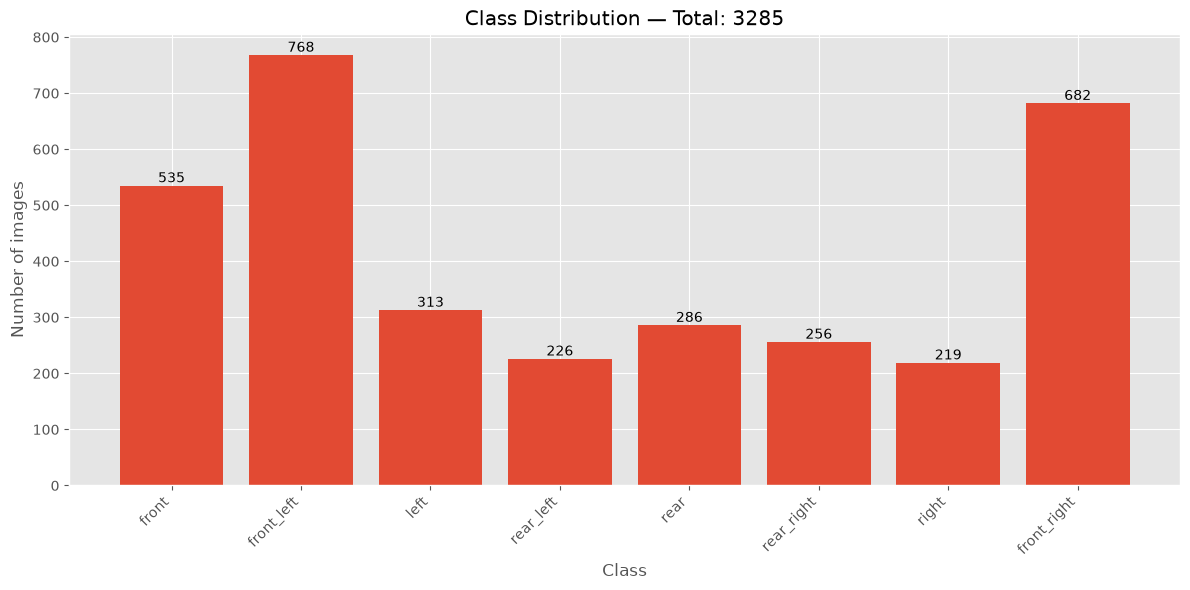

In [10]:
оrirntation_distribution_df = dataset_class_distribution(train_orientation_dataset, "оrirntation_distribution")

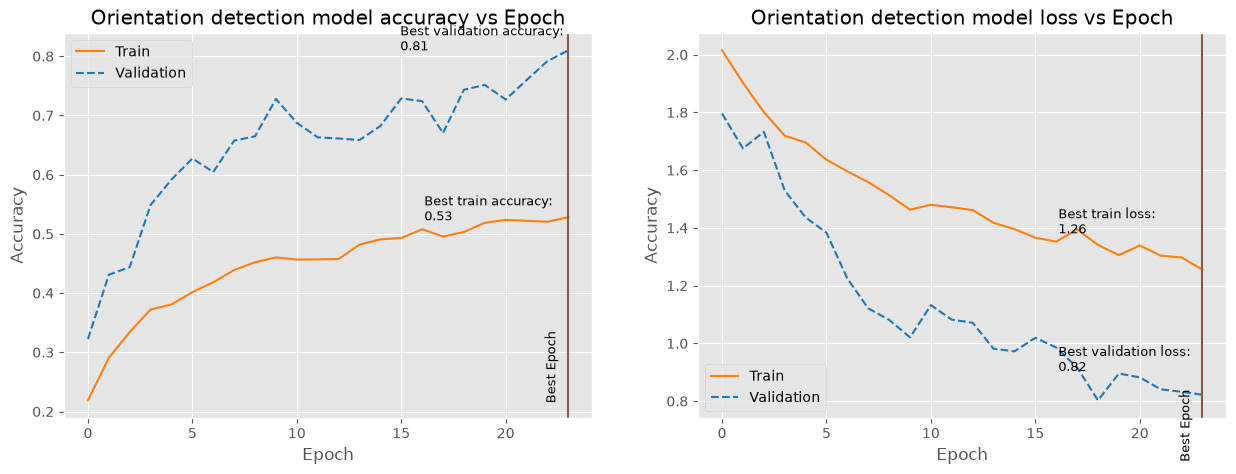

In [11]:
train_orientation_results = torch.load('./trained_pytorch_models/orientation/results_EfficientNet_B0.pth', weights_only=False)
train_val_acc_loss_plot(train_orientation_results, "Orientation detection", 'train_orientation_results')

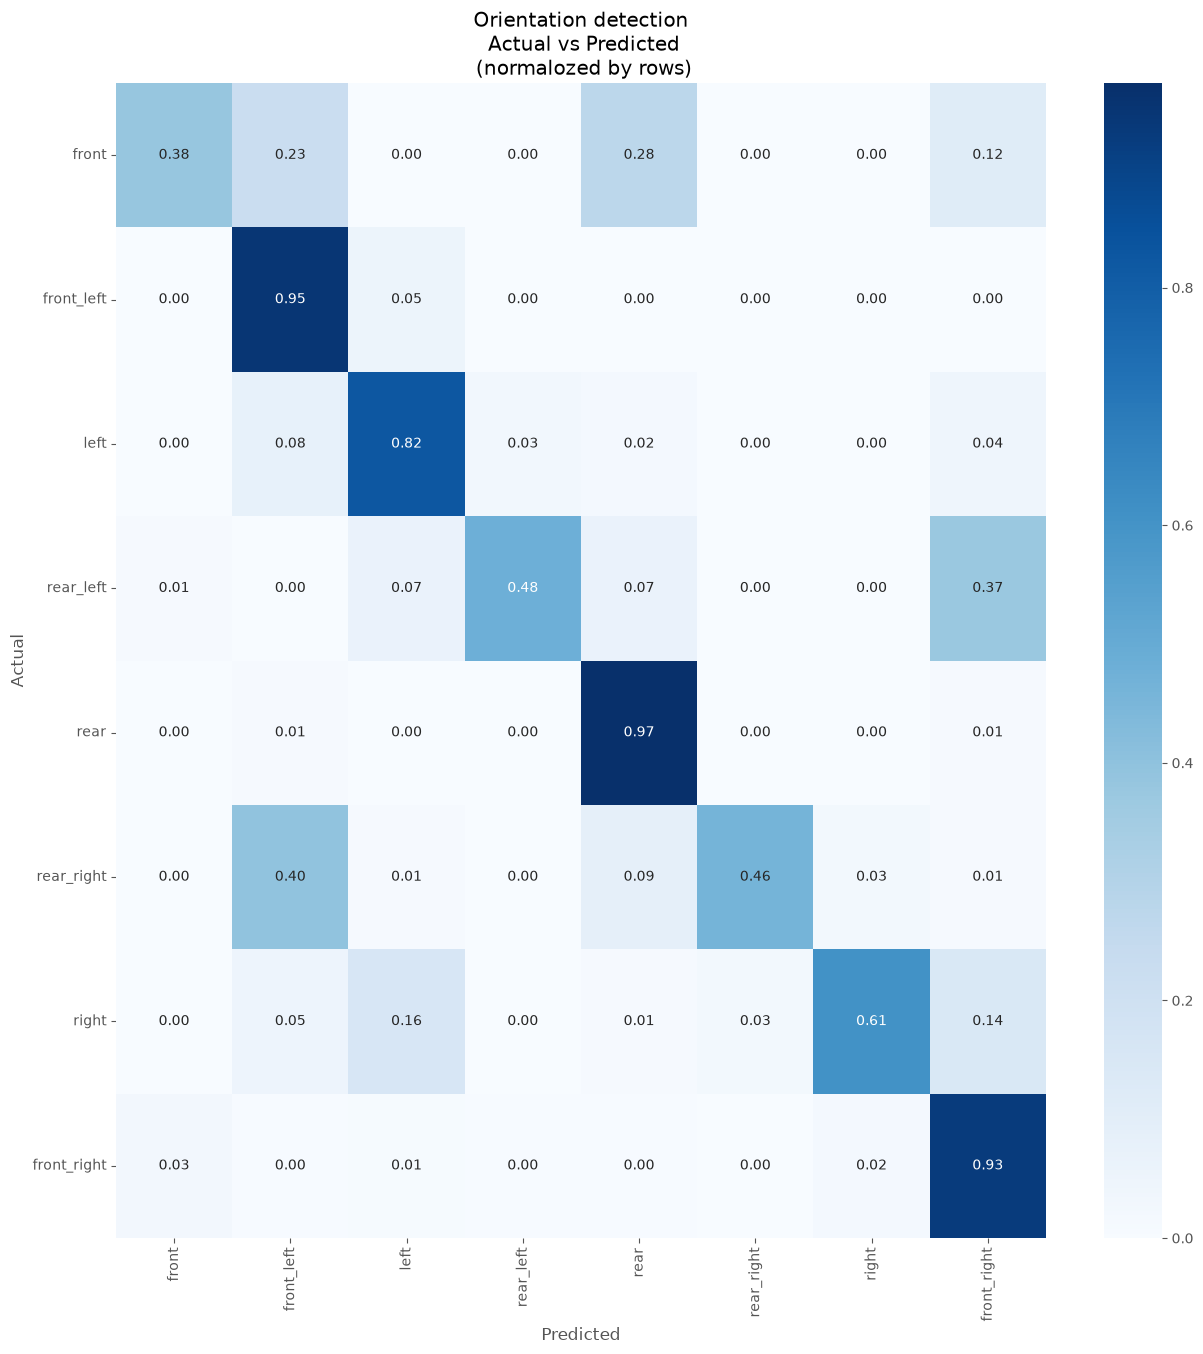

In [12]:
test_orientation_results = torch.load('./trained_pytorch_models/orientation/test_results.pth', weights_only=False)
conf_matrix_heatmap(test_orientation_results, "Orientation detection", "orientation_matrix")

## Vehicle type


Total images: 3572


,class,count
0,Bike,668
1,Bus,415
2,Car,1733
3,Truck,756


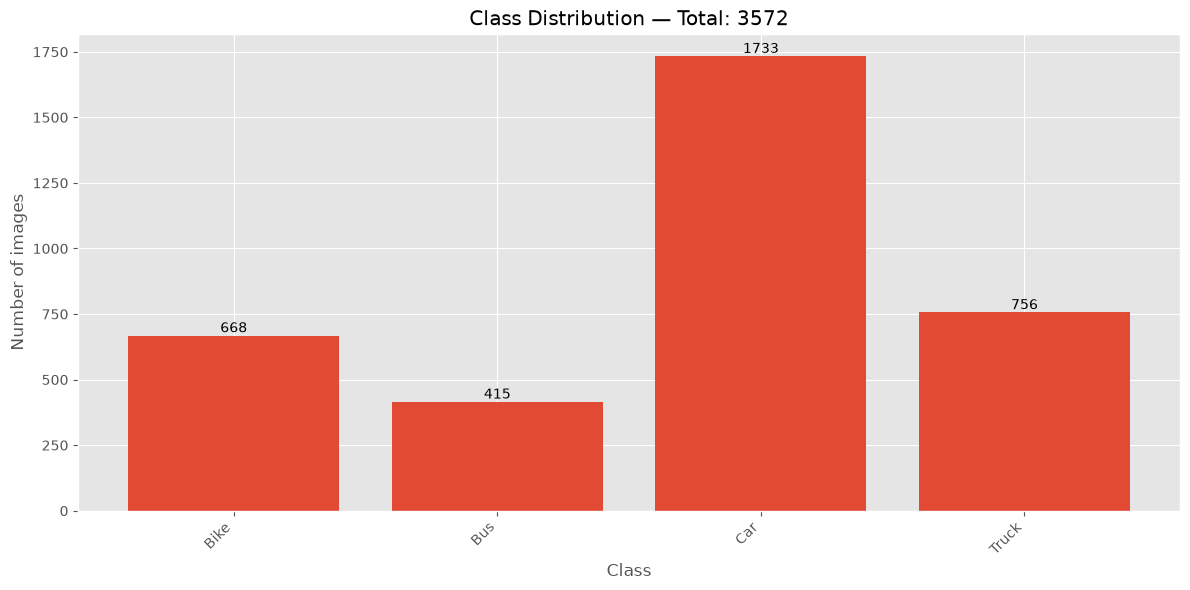

In [13]:
VEHICLE_TRAIN_TYPE_ROOT = Path("./datasets/Vehicle_type/Train/Train")
VEHICLE_TEST_TYPE_ROOT = Path("./datasets/Vehicle_type/Test")

df = pd.read_csv(Path("./datasets/Vehicle_type/Train/type-labels.csv"))

test_vehicle_type_dataset = datasets.ImageFolder(
    VEHICLE_TEST_TYPE_ROOT,
)

test_vehicle_type_loader = DataLoader(test_vehicle_type_dataset, batch_size = 64, shuffle=True)

train_vehicle_type_df, val_vehicle_type_df = train_test_split(df, 
                                                               test_size=0.3, 
                                                               random_state=RANDOM_STATE, 
                                                               shuffle=True)

train_vehicle_type_dataset = VehicleDataset(
    dataframe=train_vehicle_type_df,
    image_dir=VEHICLE_TRAIN_TYPE_ROOT,
    classes = list(test_vehicle_type_dataset.class_to_idx.keys())
)

v_type_distribution_df = dataset_class_distribution(train_vehicle_type_dataset, "v_type_distribution")

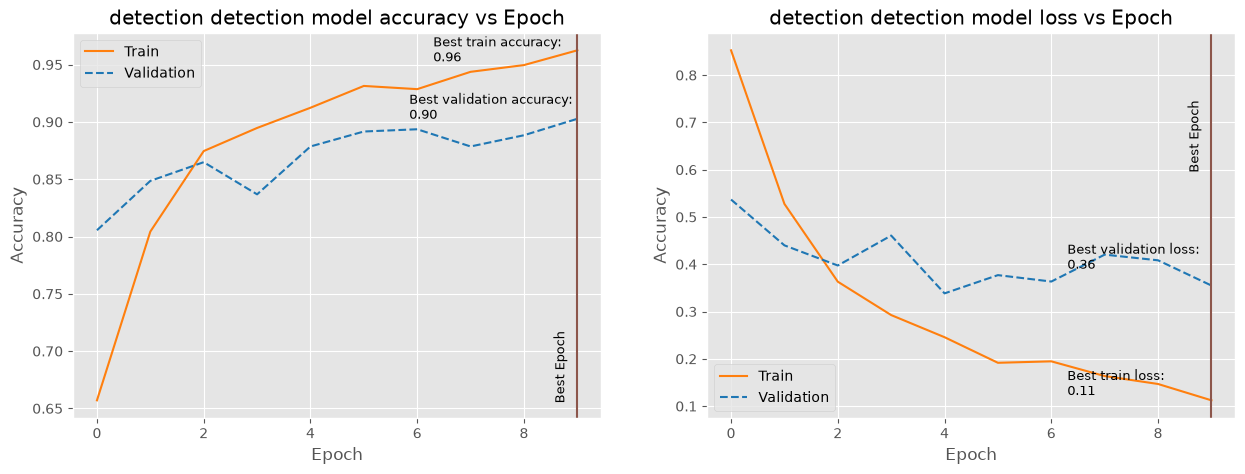

In [14]:
train_v_type_results = torch.load('./trained_pytorch_models/Vehicle_type/results_EfficientNet_B0.pth', weights_only=False)
train_val_acc_loss_plot(train_v_type_results, "detection detection", 'train_v_type_results')

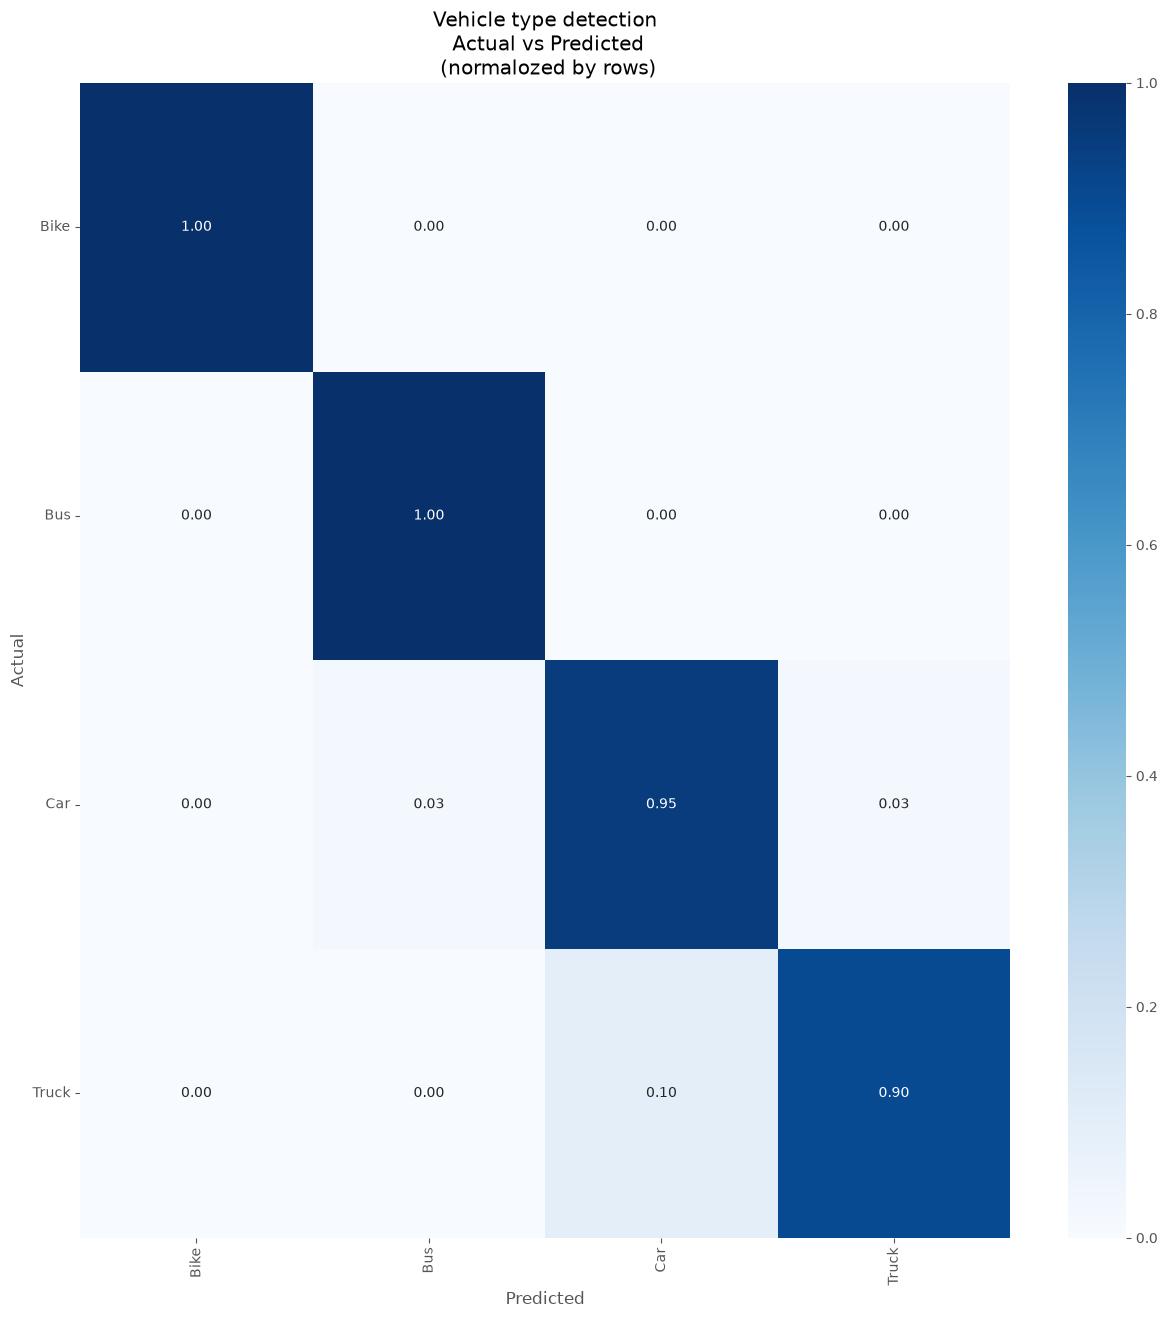

In [15]:
test_v_type_results = torch.load('./trained_pytorch_models/Vehicle_type/test_results.pth', weights_only=False)
conf_matrix_heatmap(test_v_type_results, "Vehicle type detection", "v_type_matrix")

## Car Brand detection

Total images: 41575


,class,count
0,audi,2156
1,bmw,2104
2,cadillac,818
3,chevrolet,2653
4,chrysler,279
5,dodge,671
6,ford,2857
7,genesis,429
8,gmc,839
9,honda,1318


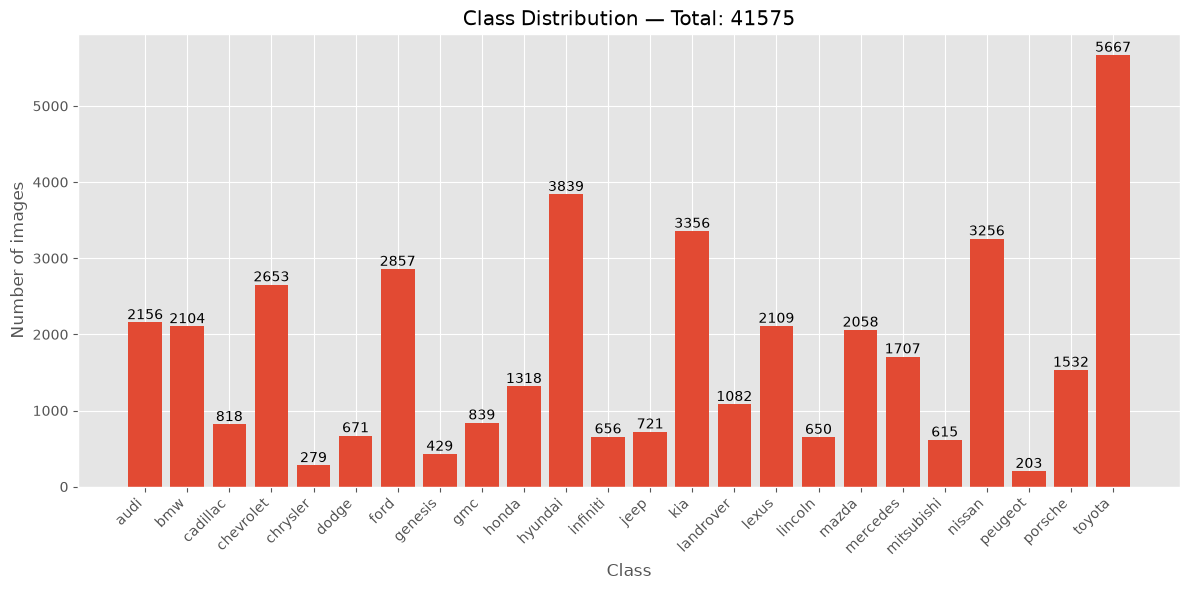

In [16]:
color_distribution_df = dataset_class_distribution("./datasets/brand_and_model", "brand_distribution")

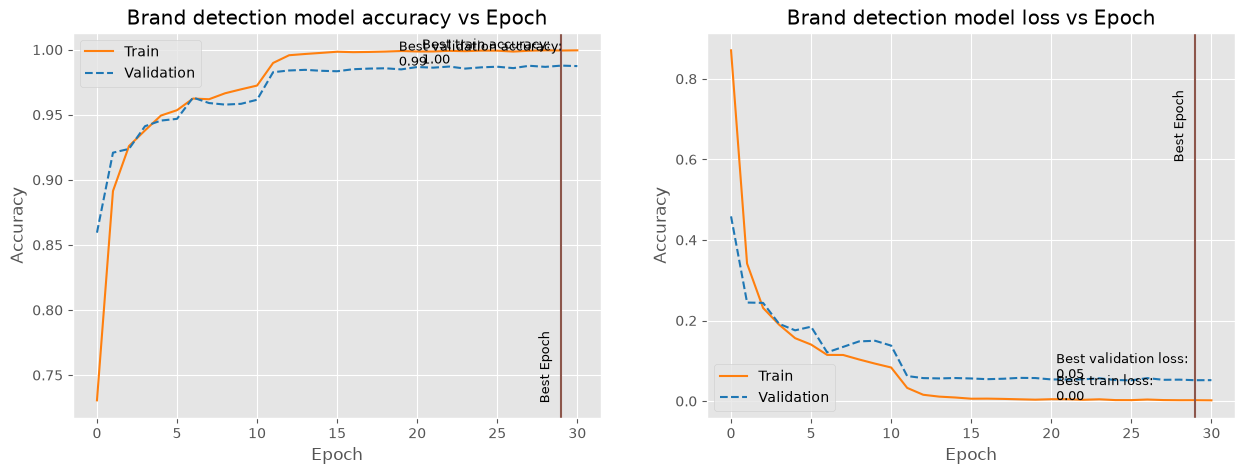

In [17]:
train_brand_results = torch.load('./trained_pytorch_models/Vehicle_brand/results_EfficientNet_B0.pth', weights_only=False)
train_val_acc_loss_plot(train_brand_results, "Brand detection", "train_brand_results")

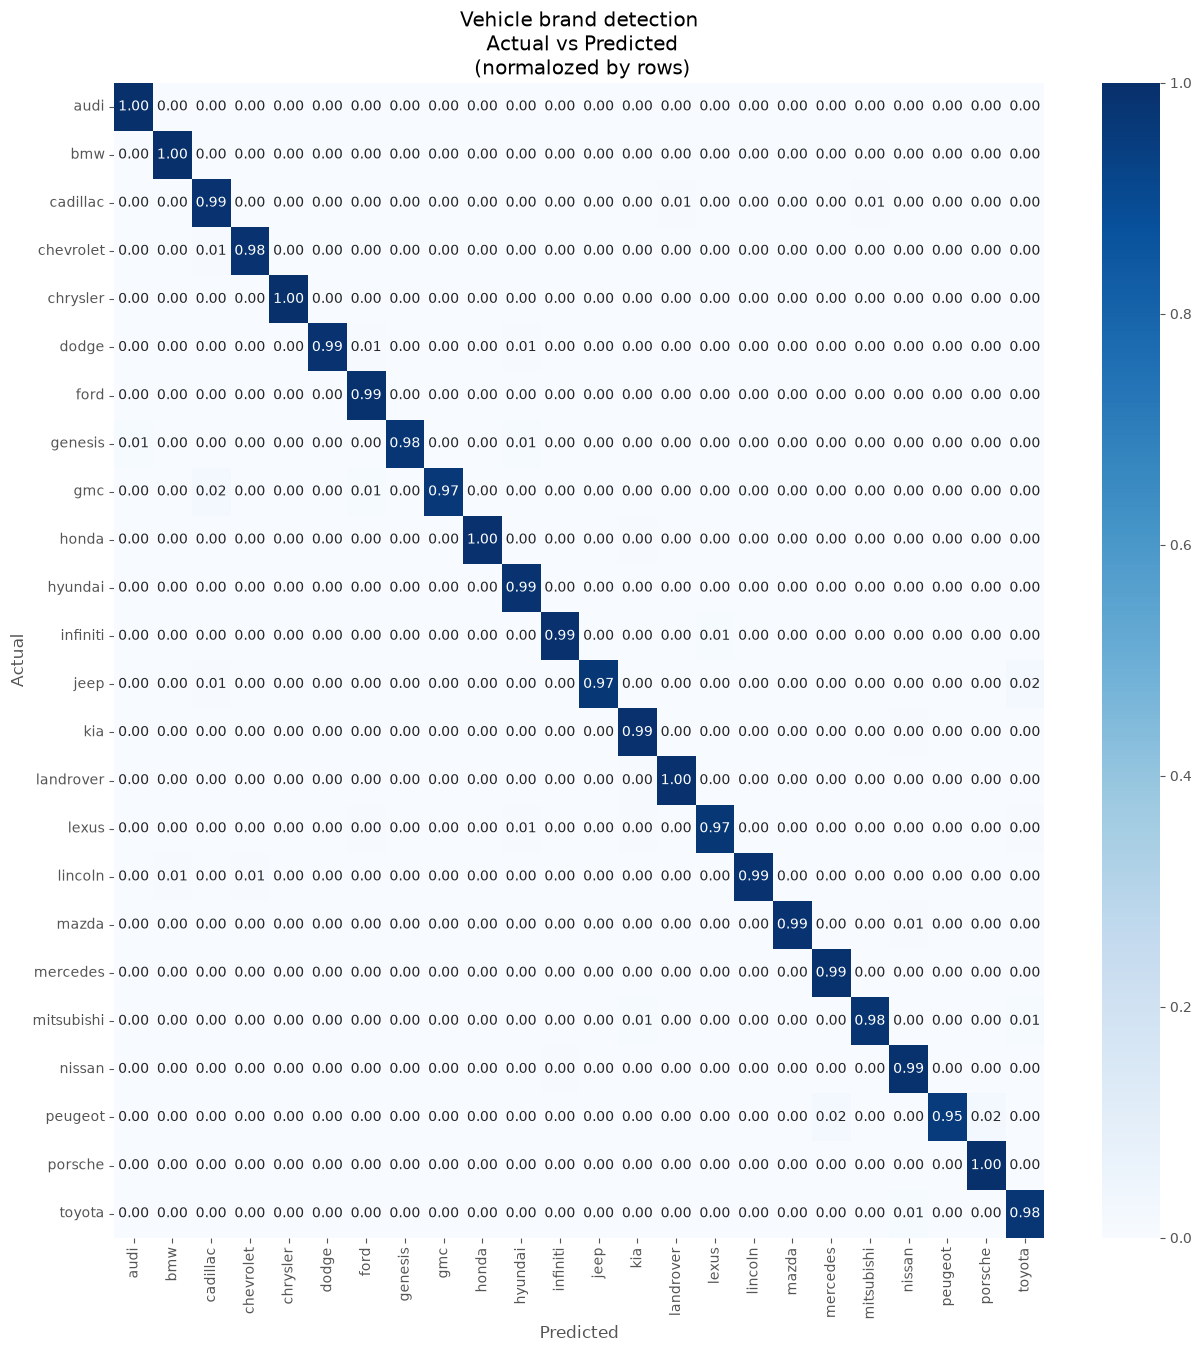

In [18]:
test_v_type_results = torch.load('./trained_pytorch_models/Vehicle_brand/test_results.pth', weights_only=False)
conf_matrix_heatmap(test_v_type_results, "Vehicle brand detection", "train_brand_matrix")

# Segmentation

In [19]:
DATASET_ROOT = Path("./datasets/parts_dataset_image_masking")

classes_df = pd.read_csv(DATASET_ROOT / "classes.csv")
num_classes = classes_df.shape[0]

display(classes_df)

mask_path = next((DATASET_ROOT / "masks").iterdir())
mask = cv2.imread(str(mask_path), cv2.IMREAD_UNCHANGED)

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

images_dir = DATASET_ROOT / "images"
masks_dir = DATASET_ROOT / "masks"

image_paths = sorted(
    path for path in images_dir.iterdir()
    if path.suffix.lower() in IMAGE_EXTENSIONS
)

mask_by_stem = {
    path.stem: path
    for path in masks_dir.iterdir()
    if path.suffix.lower() in IMAGE_EXTENSIONS
}

mask_samples = []

for image_path in image_paths:
    mask_path = mask_by_stem.get(image_path.stem)

    if mask_path is None:
        print("No mask:", image_path.name)
        continue

    mask_samples.append((image_path, mask_path))
    
train_mask_samples, temp_mask_samples = train_test_split(
    mask_samples,
    test_size=0.4,
    random_state=42,
)


train_mask_dataset = CarPartsSegmentationDataset(
    train_mask_samples
)

,class,color
0,background,#000000
1,hood,#4355CB
2,trunk,#E5F83A
3,windshield,#9C969D
4,rear window,#320698
5,headlight,#2E7F62
6,tail light,#903765
7,front door,#E62D30
8,rear door,#7C93DA
9,front bumper,#4AF778


In [20]:
print(train_mask_dataset.samples[0])

(PosixPath('datasets/parts_dataset_image_masking/images/2202.png'), PosixPath('datasets/parts_dataset_image_masking/masks/2202.png'))


Total pixels: 109,684,736


,class,pixels,percent
0,background,39762251,36.251399
1,hood,7385267,6.733177
2,trunk,6506389,5.931900
3,windshield,5715780,5.211099
4,rear window,2238309,2.040675
5,headlight,2031928,1.852517
6,tail light,1436116,1.309313
7,front door,8842667,8.061894
8,rear door,6986126,6.369278
9,front bumper,15966806,14.556999


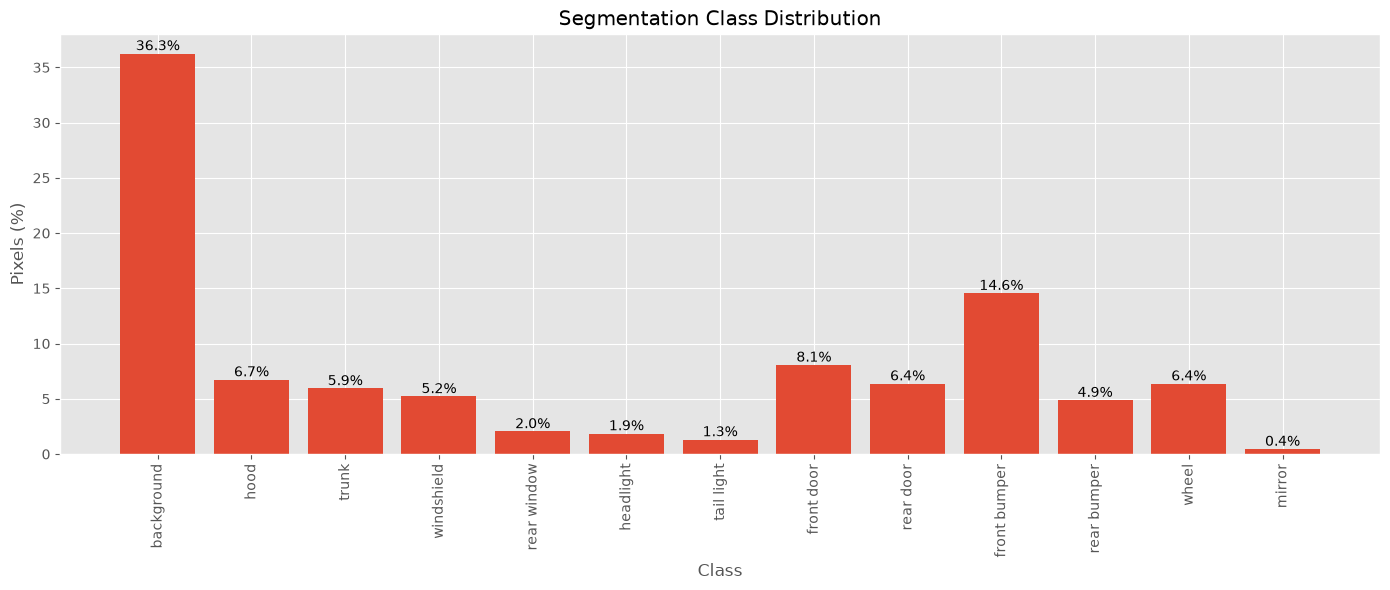

In [21]:
segmentation_distribution_df = segmentation_class_distribution(train_mask_dataset, './datasets/parts_dataset_image_masking/classes.csv', "segmentation_distribution")

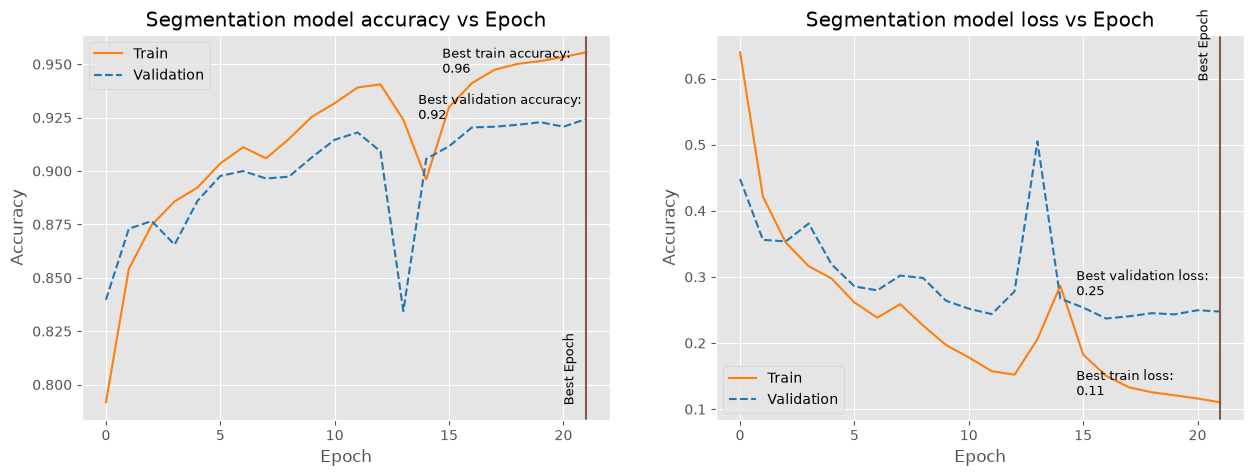

In [22]:
train_seg_results = torch.load('./trained_pytorch_models/parts_segmentation/results_resnext50.pth', weights_only=False)
train_val_acc_loss_plot(train_seg_results, "Segmentation", "train_seg_results")

# Parts detection

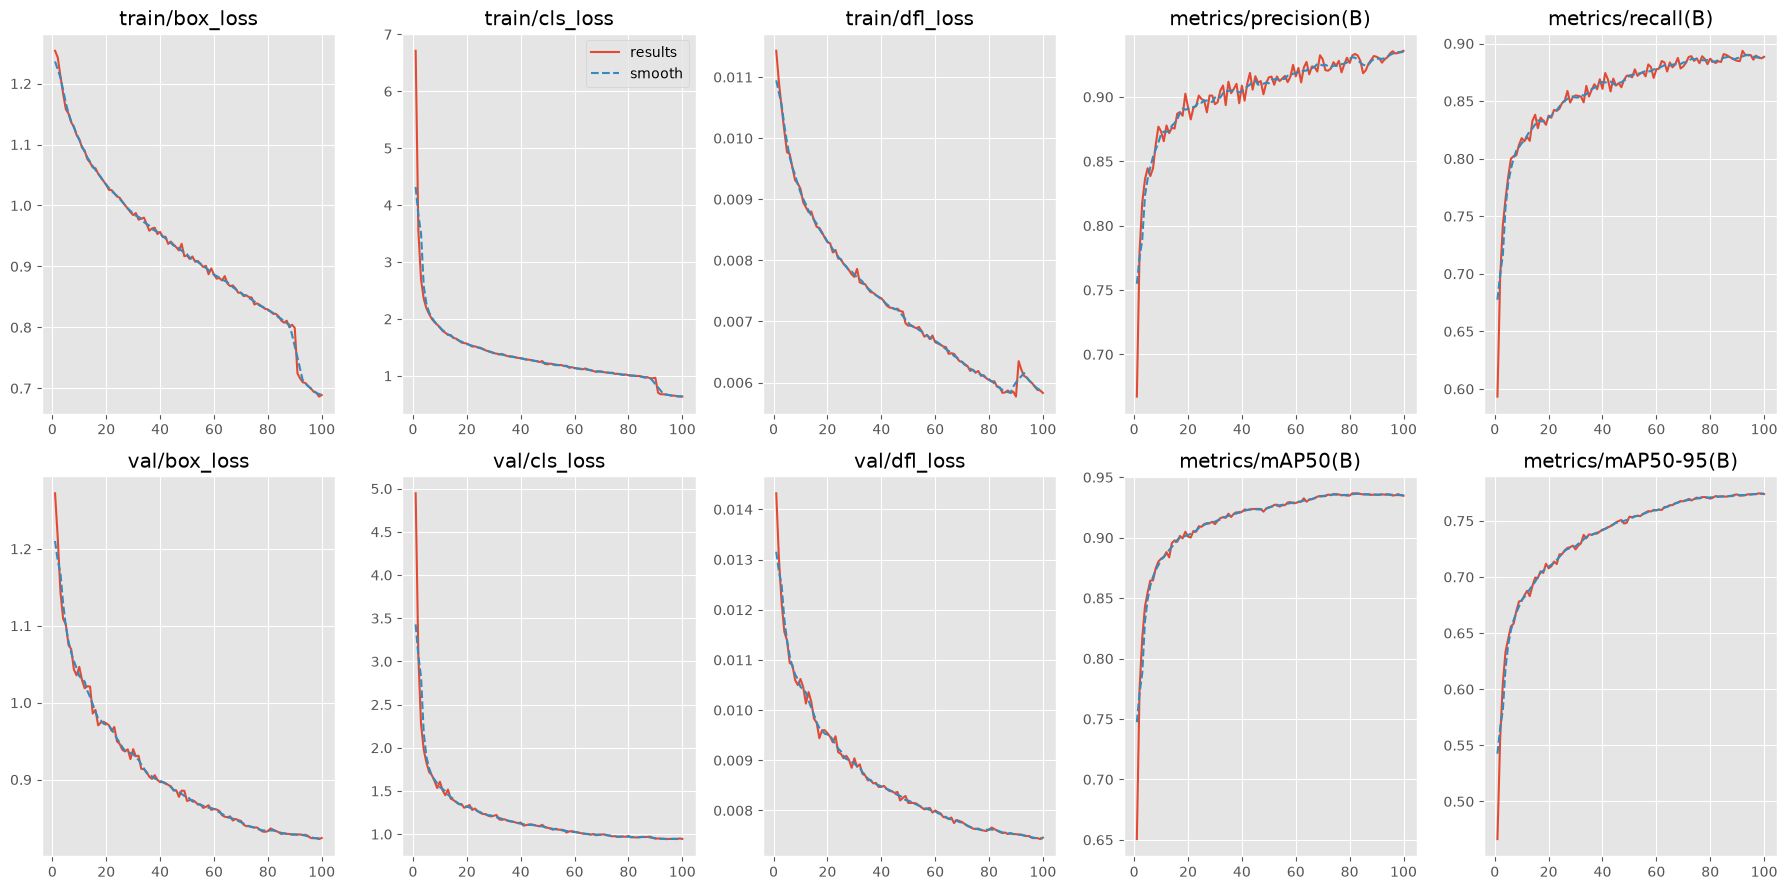

In [23]:
plot_yolo_training_results("./runs/detect/parts/train_best/results.csv", "parts_detection_resilts", plot_colors[0], plot_colors[1])

With: <br>
conf — Confidence threshold = 0.25, <br>
IoU — Intersection over Union = 0.7

Ultralytics 8.4.108 🚀 Python-3.11.15 torch-2.13.0+cu130 CUDA:0 (NVIDIA GeForce RTX 3060 Ti, 7823MiB)
YOLO26n summary (fused): 122 layers, 2,378,931 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3583.8±884.6 MB/s, size: 42.0 KB)
val: Scanning /home/ilia/Desktop/AVIS_final_project/datasets/parts_dataset/labels/val.cache... 735 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 735/735 385.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 46/46 15.0it/s 3.1s0.1s
                   all        735       9535      0.935      0.888      0.897       0.75
Speed: 0.5ms preprocess, 2.4ms inference, 0.0ms loss, 0.1ms postprocess per image
Results saved to /home/ilia/Desktop/AVIS_final_project/runs/detect/val-41


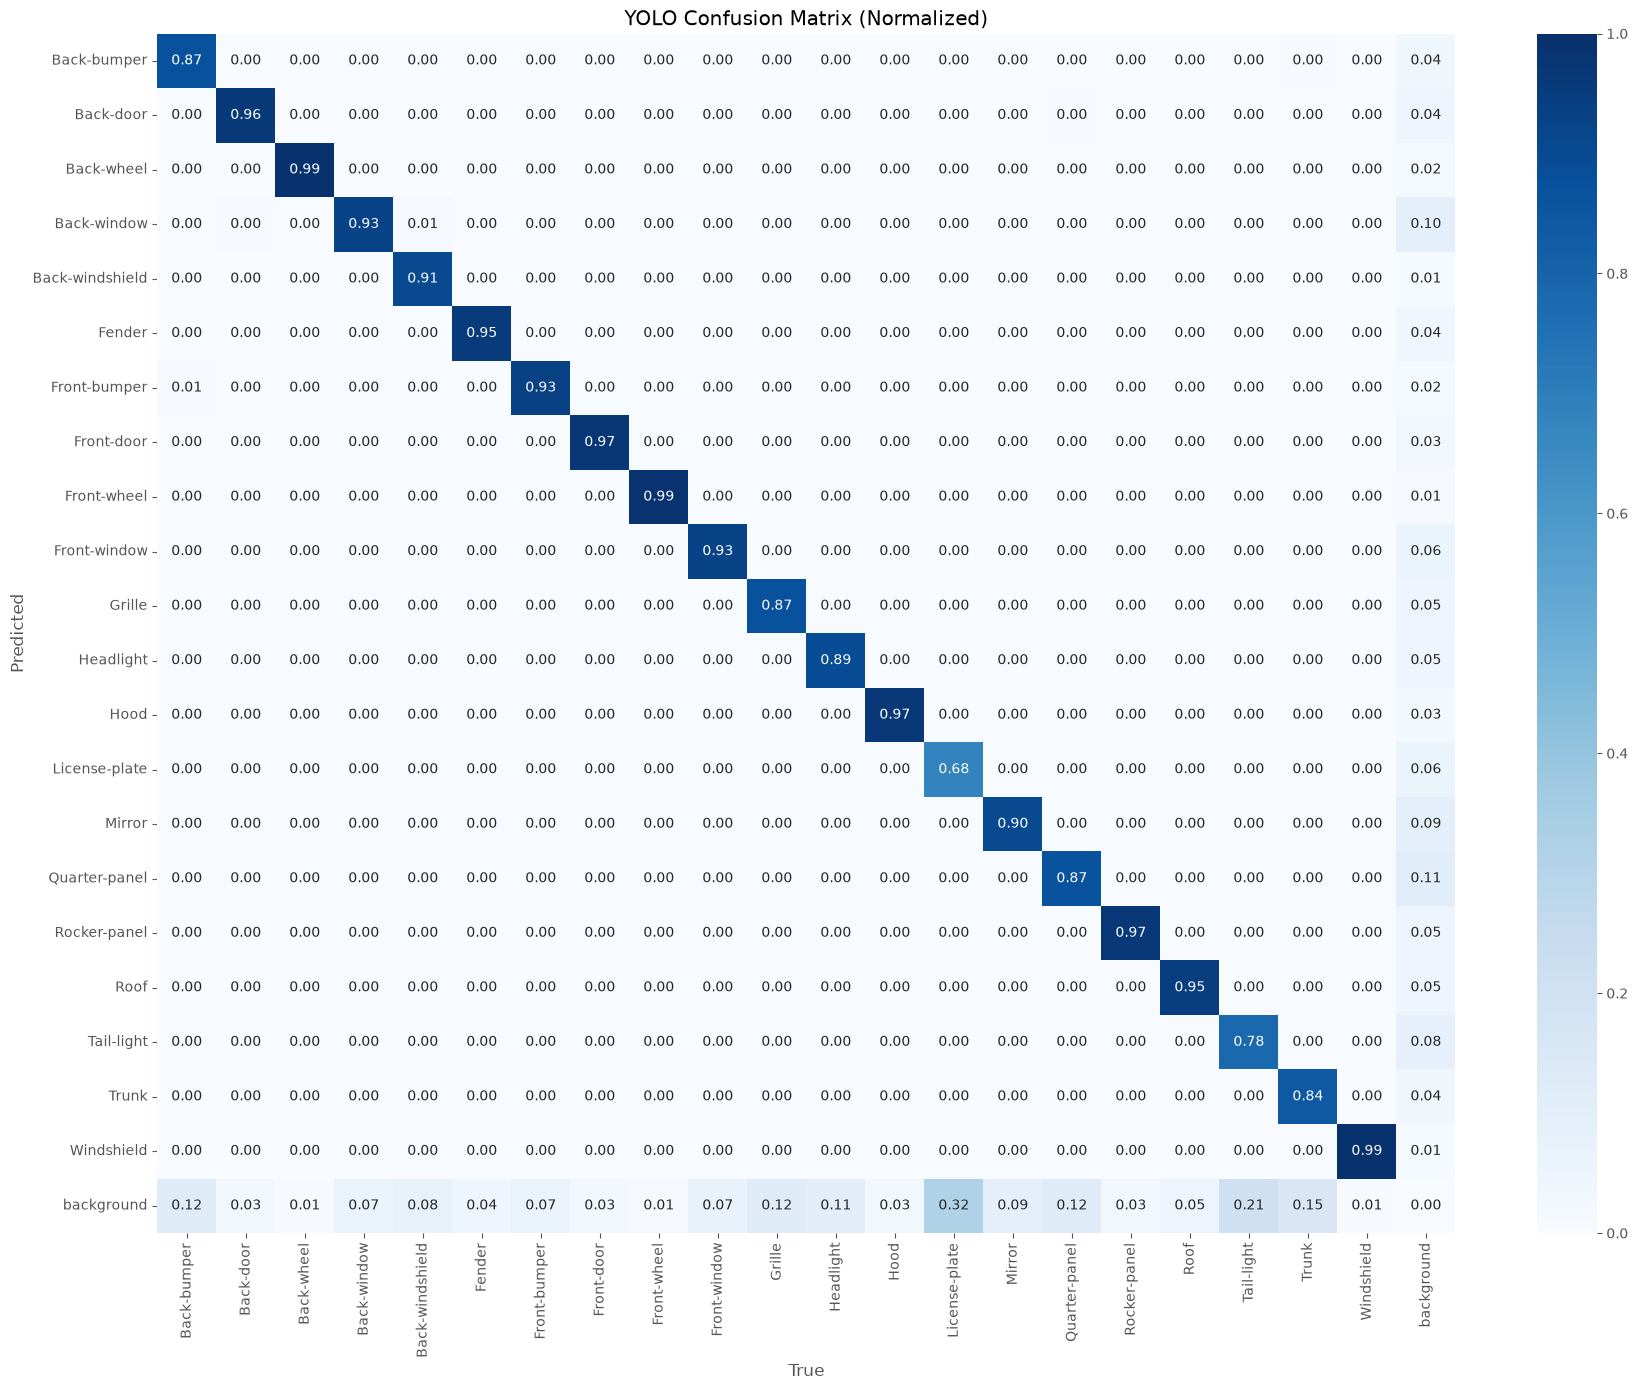

In [24]:
plot_conf_matrix_yolo(
    "./runs/detect/parts/train_best/weights/best.pt",
    "./datasets/parts_dataset/data.yaml",
    "parts_detection_matrix",
    conf=0.25,
    iou=0.7
)

# License plate detection

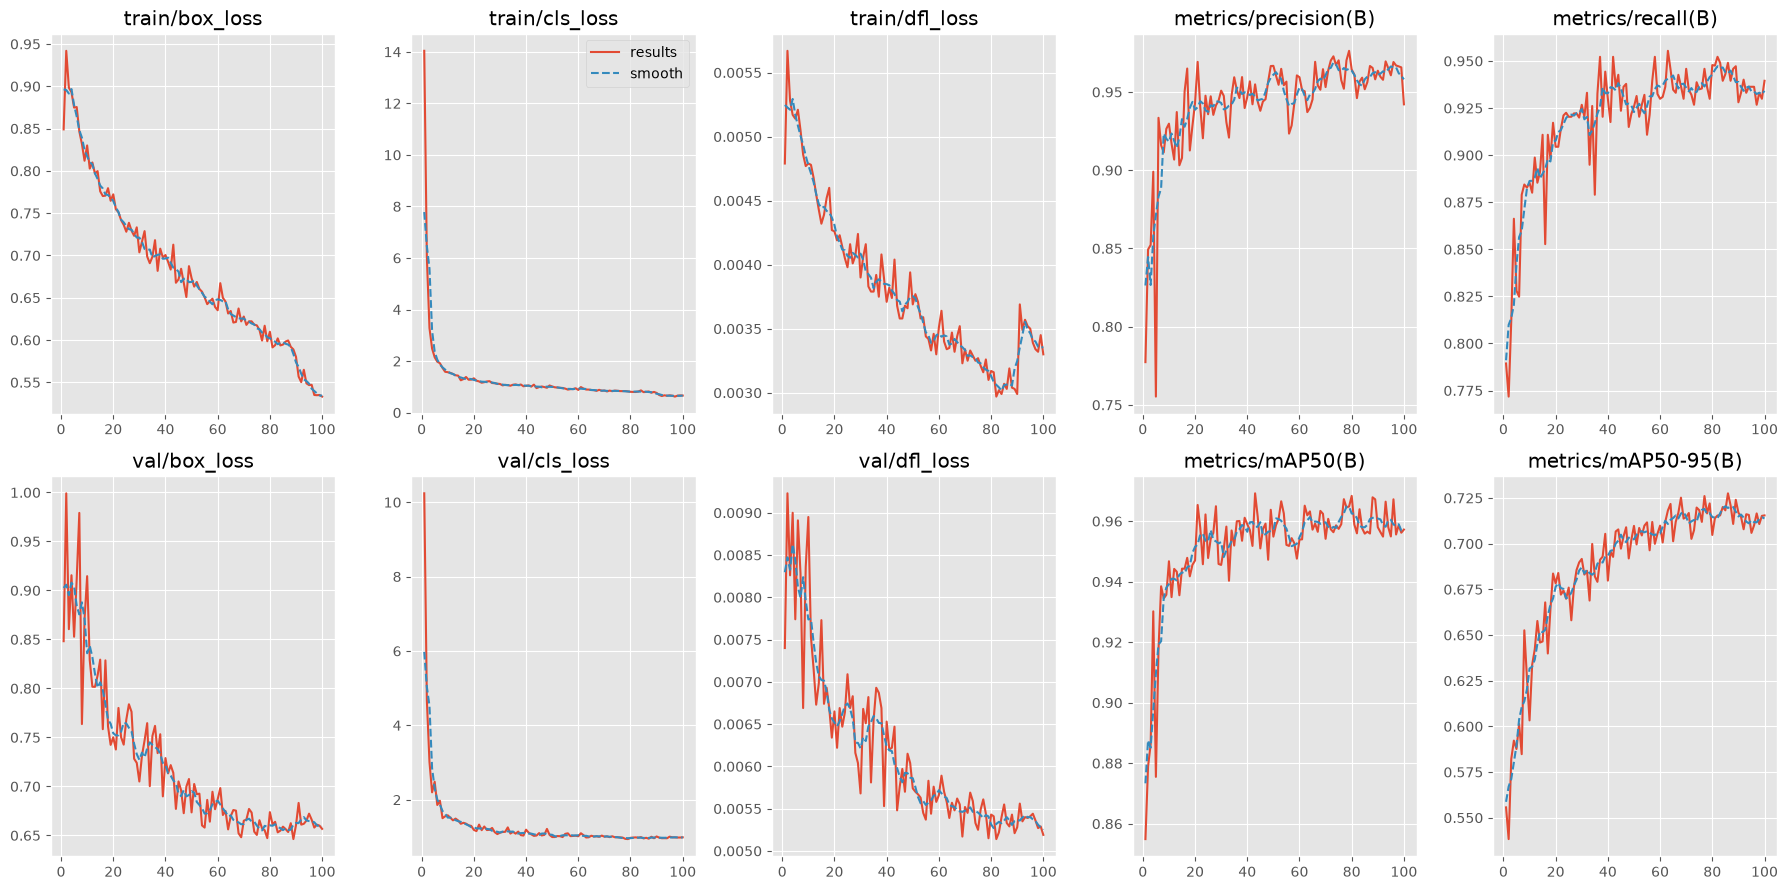

In [25]:
plot_yolo_training_results("./runs/detect/license_plate/train_best/results.csv", "license_plate_detection_results", plot_colors[0], plot_colors[1])

Ultralytics 8.4.108 🚀 Python-3.11.15 torch-2.13.0+cu130 CUDA:0 (NVIDIA GeForce RTX 3060 Ti, 7823MiB)
YOLO26n summary (fused): 122 layers, 2,375,031 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 6372.6±829.8 MB/s, size: 179.8 KB)
val: Scanning /home/ilia/Desktop/AVIS_final_project/datasets/license_plate/labels/val.cache... 302 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 302/302 211.1Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 19/19 13.0it/s 1.5s0.1s
                   all        302        314      0.973      0.911      0.912      0.697
Speed: 0.6ms preprocess, 2.5ms inference, 0.0ms loss, 0.1ms postprocess per image
Results saved to /home/ilia/Desktop/AVIS_final_project/runs/detect/val-42


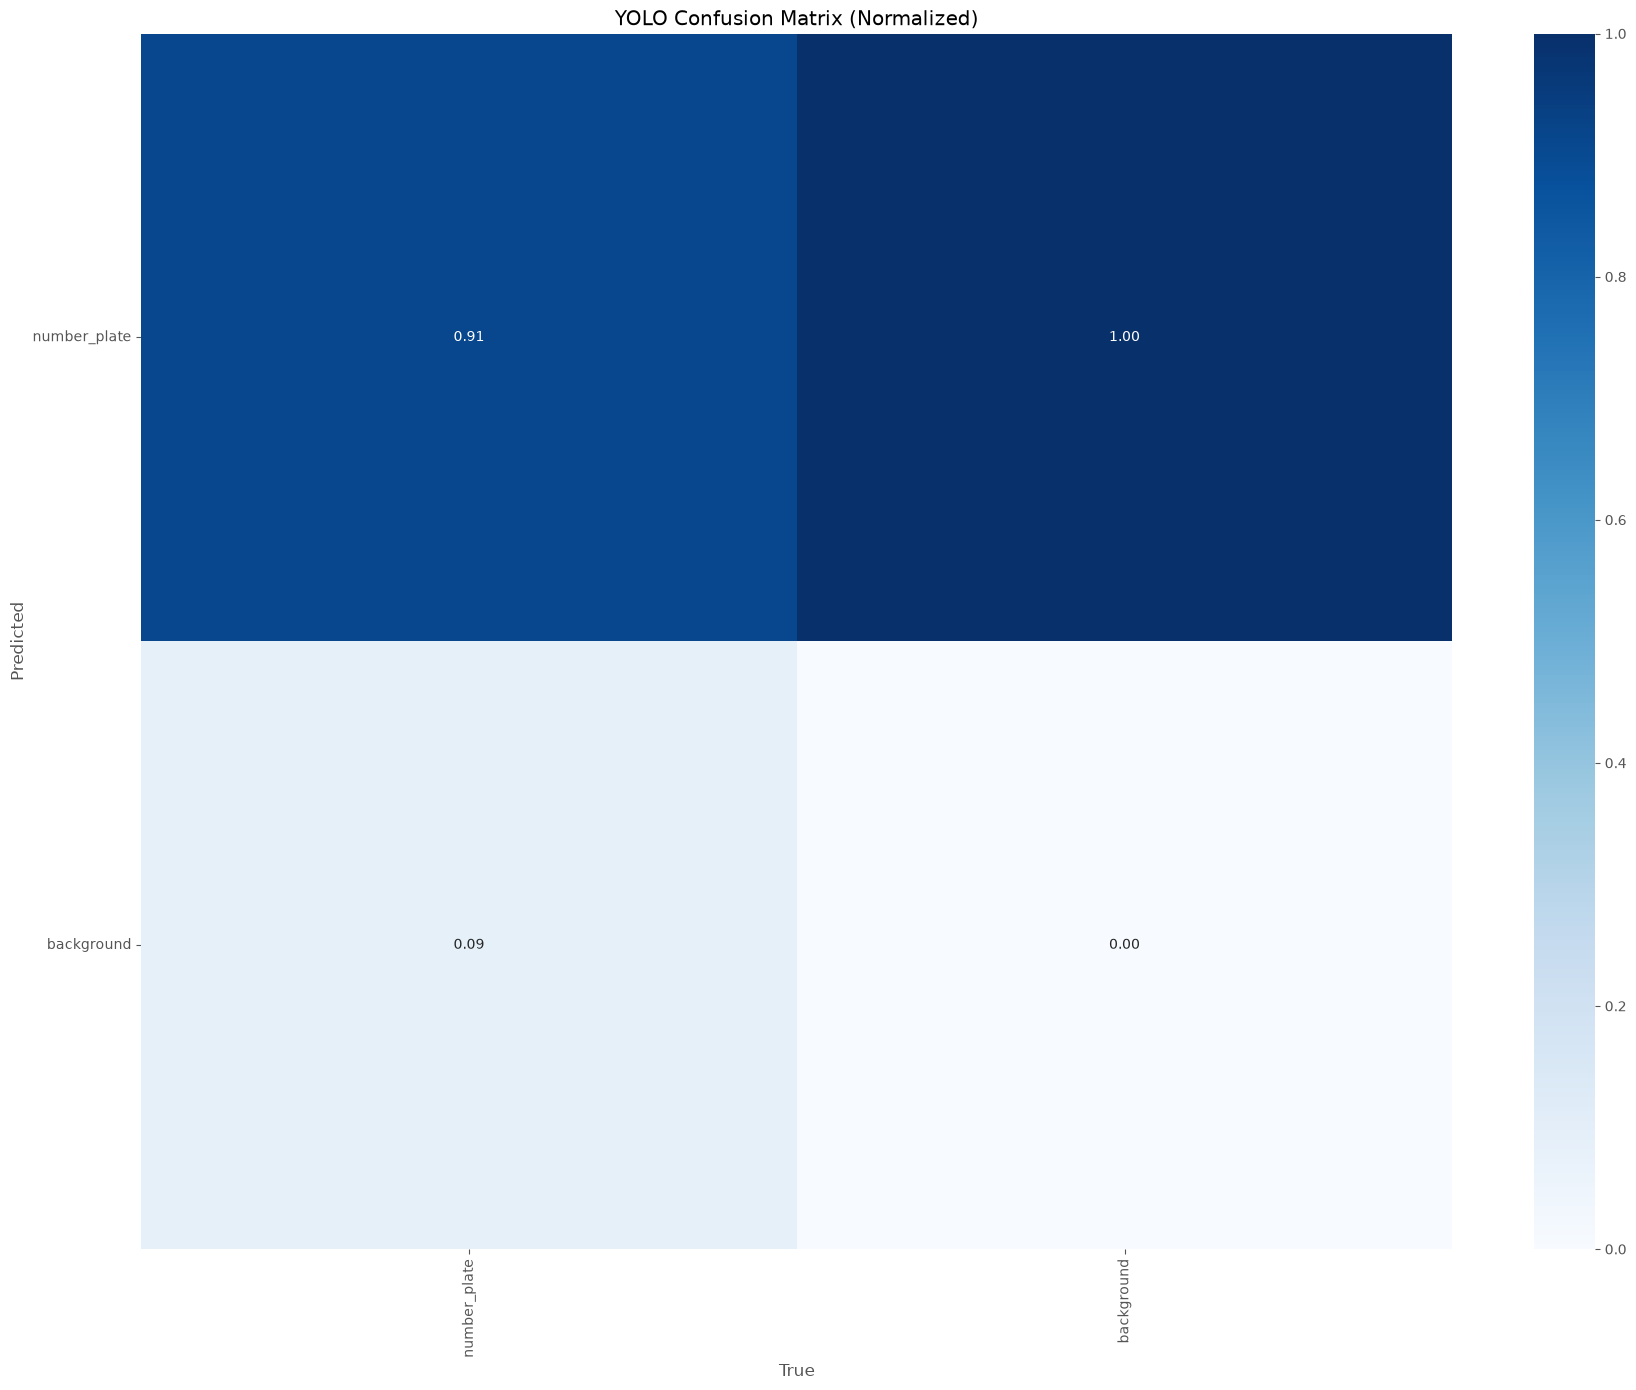

In [26]:
plot_conf_matrix_yolo(
    "./runs/detect/license_plate/train_best/weights/best.pt",
    "./datasets/license_plate/data.yaml",
    "license_plate_detection_matrix",
    conf=0.7,
    iou=0.7
)

# Damage type detection

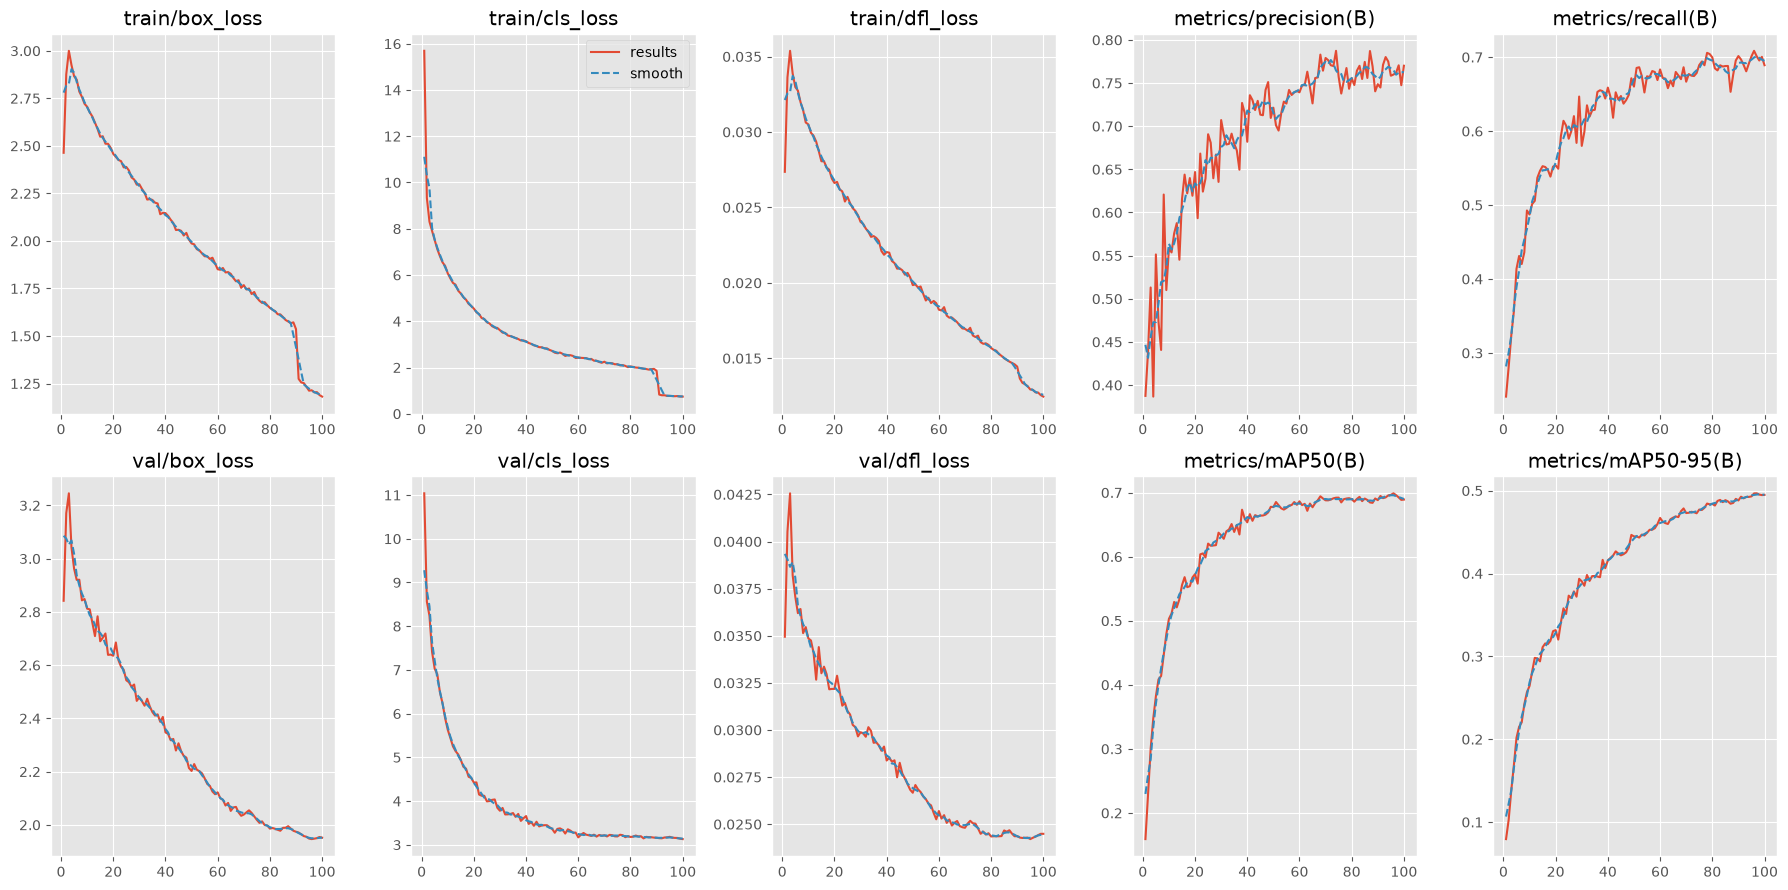

In [27]:
plot_yolo_training_results("./runs/detect/damage_type/train_best/results.csv", "damage_ytpe_detection_results", plot_colors[0], plot_colors[1])

Ultralytics 8.4.108 🚀 Python-3.11.15 torch-2.13.0+cu130 CUDA:0 (NVIDIA GeForce RTX 3060 Ti, 7823MiB)
YOLO26n summary (fused): 122 layers, 2,376,201 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2570.5±964.7 MB/s, size: 44.7 KB)
val: Scanning /home/ilia/Desktop/AVIS_final_project/datasets/damage_type/valid/labels.cache... 1446 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1446/1446 673.9Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 91/91 17.4it/s 5.2s0.1s
                   all       1446       2335      0.791      0.681      0.646      0.469
Speed: 0.5ms preprocess, 2.1ms inference, 0.0ms loss, 0.1ms postprocess per image
Results saved to /home/ilia/Desktop/AVIS_final_project/runs/detect/val-43


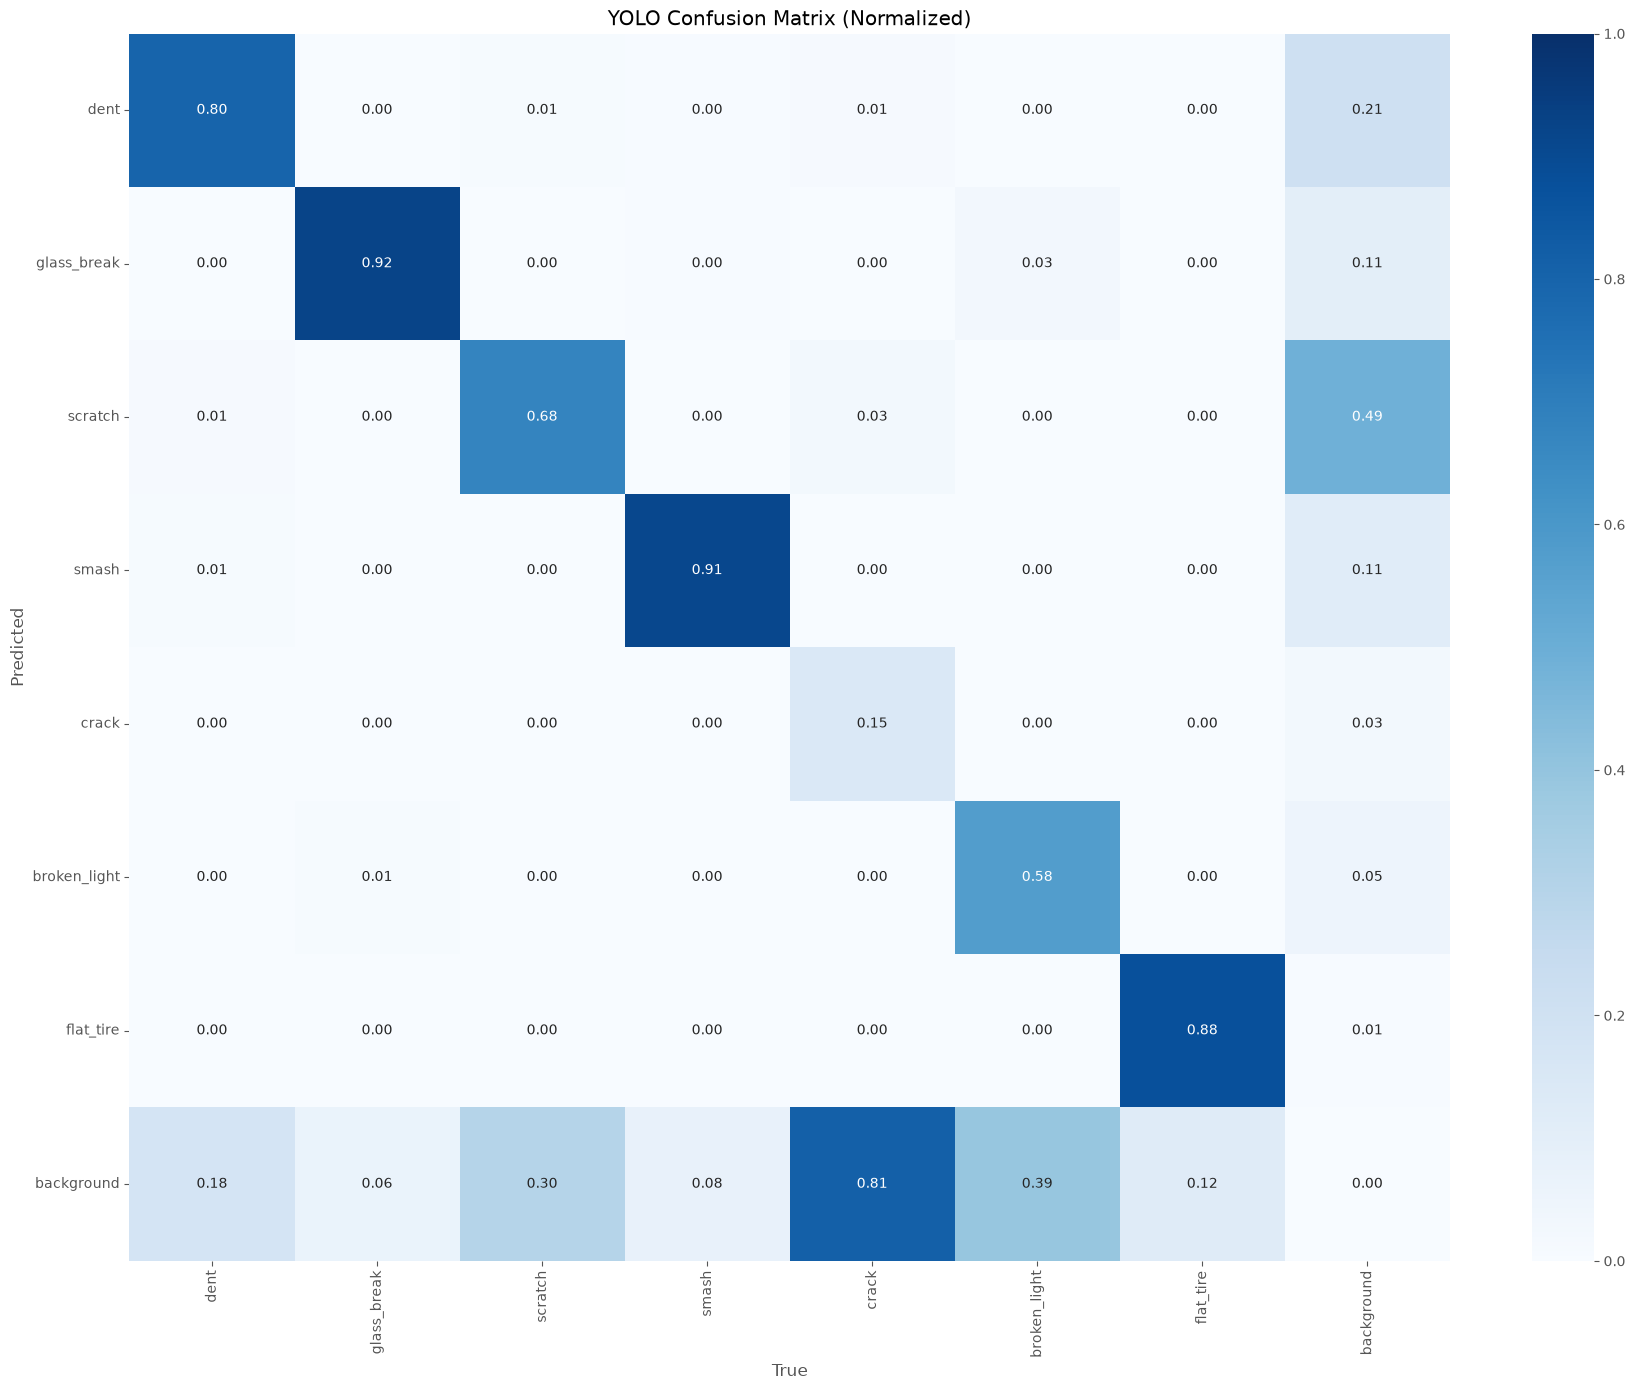

In [28]:
plot_conf_matrix_yolo(
    "./runs/detect/damage_type/train_best/weights/best.pt",
    "./datasets/damage_type/data.yaml",
    "damage_ytpe_detection_matrix",
    conf=0.25,
    iou=0.7
)

# NLP models

## GPT 2

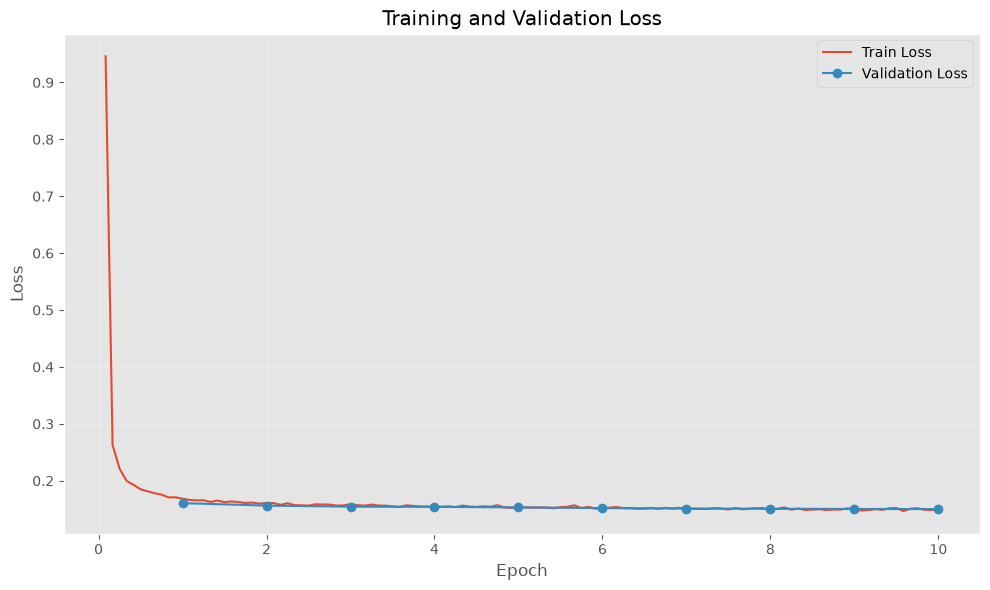

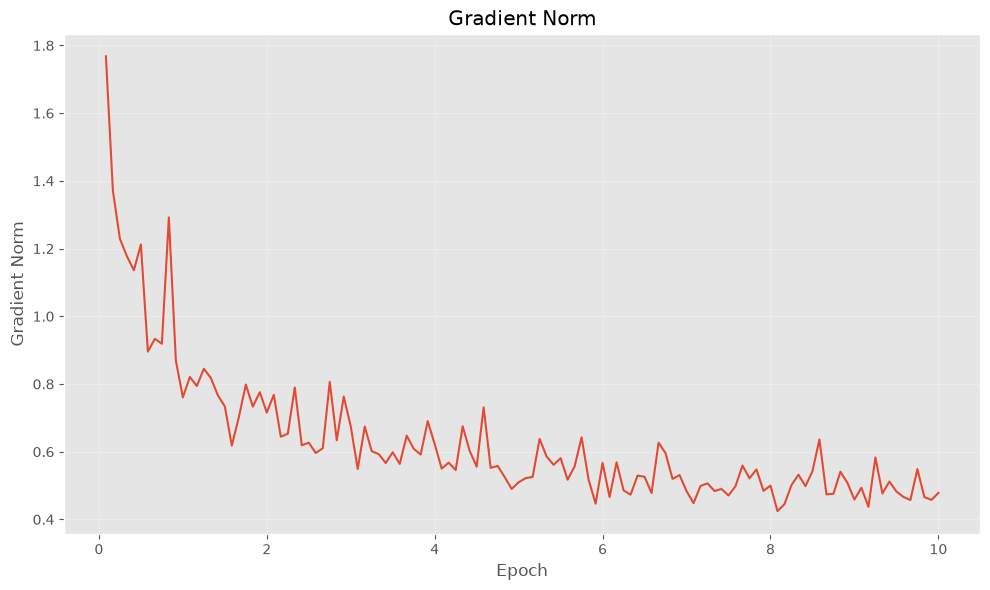

In [29]:
gpt2_history = plot_nlp_training_results(
    "./trained_models/gpt2/best", 
    "gpt2"
)

## FLAN-T5 small

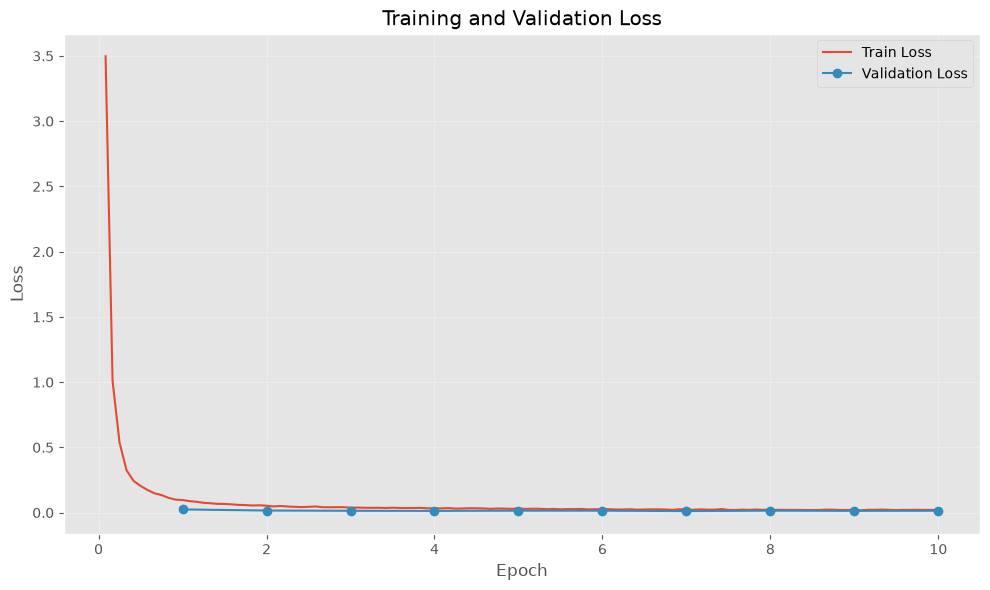

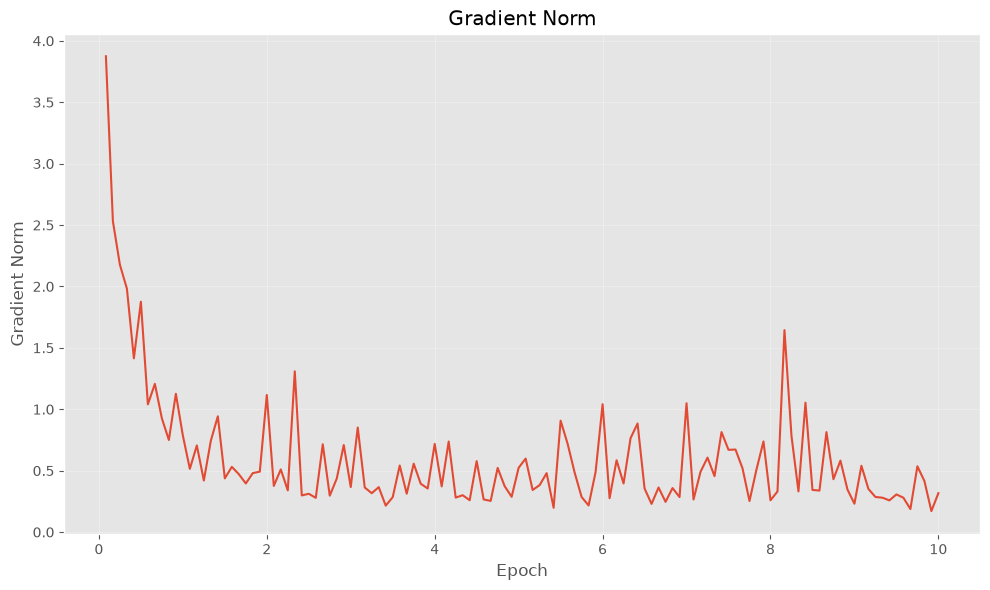

In [30]:
flan_а5_history = plot_nlp_training_results("./trained_models/flan-t5-small/best", "flan_а5")

## BART base

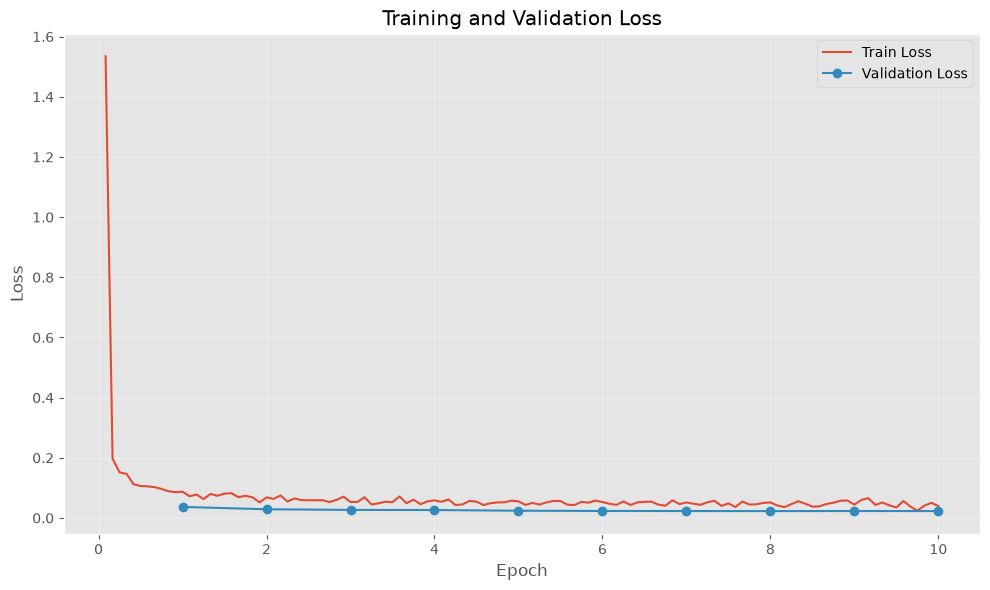

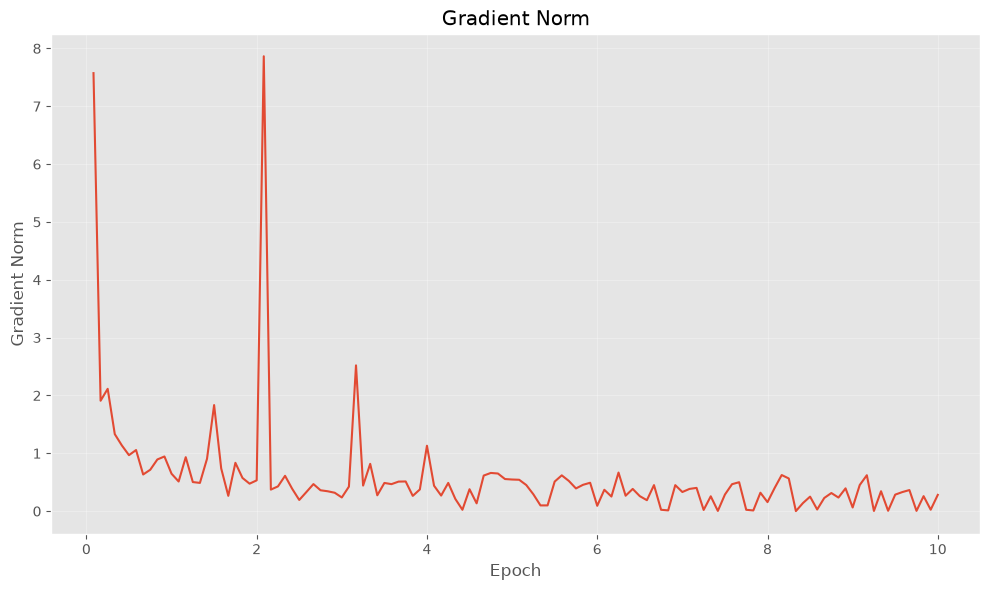

In [31]:
bart_base_history = plot_nlp_training_results("./trained_models/bart-base/best", "bart_base")